# Model Interpretation - CatBoost


## 1. Zielsetzung und methodische Einordnung

Notebook 02 untersucht das in Notebook 01 festgelegte getunte CatBoost-Modell. Es findet keine erneute Modellauswahl, keine weitere Hyperparametersuche und kein Vergleich mit anderen Modellklassen statt.

Die Analyse betrachtet ausschließlich die prognostische Bedeutung der externen Zeit-, Kalender- und Wettermerkmale für die Modellvorhersage. CatBoost verarbeitet die festgelegten kategorialen Features nativ; ein One-Hot-Encoding wird hier nicht verwendet.

Die Methodik bleibt unverändert: Training auf November 2025 bis Juni 2026, Validierung und Interpretation auf Juli 2026. Die zugrunde liegenden Splits verwenden die aktualisierte Boundary-Exclusion-Logik; Fahrten über Split-Grenzen sind also bereits aus Training und Validation entfernt. Der Testdatensatz August 2026 wird nicht geladen oder verwendet.

Permutation Importance und Partial Dependence beschreiben modellinterne bzw. prognostische Zusammenhänge. Sie sind nicht als kausale Effekte zu verstehen. Aufgrund der insgesamt geringen Modellgüte müssen die Interpretationen vorsichtig gelesen werden.

## 2. Setup


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


PROJECT_DIR = Path.cwd()

while not (PROJECT_DIR / "datasets").exists():
    if PROJECT_DIR == PROJECT_DIR.parent:
        raise FileNotFoundError("Could not find project directory with datasets/.")
    PROJECT_DIR = PROJECT_DIR.parent

FEATURE_DIR = PROJECT_DIR / "datasets" / "modeling" / "features"
TRAIN_PATH = FEATURE_DIR / "train_features.parquet"
VALIDATION_PATH = FEATURE_DIR / "validation_features.parquet"

TRAIN_PERIOD = "November 2025 bis Juni 2026"
VALIDATION_PERIOD = "Juli 2026"

## 3. Daten laden


In [2]:
train = pd.read_parquet(TRAIN_PATH)
validation = pd.read_parquet(VALIDATION_PATH)

external_features = [
    "event_hour",
    "event_weekday",
    "is_public_holiday",
    "ff_wind_speed_ms",
    "wind_direction_sin",
    "wind_direction_cos",
    "fx_wind_gust_ms",
    "tu_temperature_c",
    "tu_relative_humidity_pct",
    "rr_precipitation_mm",
    "rr_precipitation_indicator",
    "rr_precipitation_form",
]

y_train = train["delay_target"]
y_validation = validation["delay_target"]

X_train = train[external_features].copy()
X_validation = validation[external_features].copy()

dataset_overview = pd.DataFrame(
    {
        "Dataset": ["Training", "Validation"],
        "Period": [TRAIN_PERIOD, VALIDATION_PERIOD],
        "Observations": [len(train), len(validation)],
        "Features": [X_train.shape[1], X_validation.shape[1]],
    }
)

dataset_overview

,Dataset,Period,Observations,Features
0,Training,November 2025 bis Juni 2026,689684,12
1,Validation,Juli 2026,73867,12


## 4. Features und CatBoost-Aufbereitung

Die Feature-Auswahl und Aufbereitung entspricht der CatBoost-Logik aus Notebook 01. Es werden ausschließlich die zwölf externen bzw. exogenen Features verwendet.

`event_hour`, `event_weekday` und `rr_precipitation_form` werden als kategoriale CatBoost-Features behandelt. Fehlende Werte dieser kategorialen Features werden als `"missing"` gesetzt und anschließend als Strings übergeben. Numerische Missing Values werden nicht vorab imputiert, sondern wie in Notebook 01 direkt an CatBoost übergeben.

In [3]:
categorical_features = [
    "event_hour",
    "event_weekday",
    "rr_precipitation_form",
]

numeric_features = [
    "is_public_holiday",
    "ff_wind_speed_ms",
    "wind_direction_sin",
    "wind_direction_cos",
    "fx_wind_gust_ms",
    "tu_temperature_c",
    "tu_relative_humidity_pct",
    "rr_precipitation_mm",
    "rr_precipitation_indicator",
]

model_features = categorical_features + numeric_features

X_train_model = X_train[model_features].copy()
X_validation_model = X_validation[model_features].copy()

for column in categorical_features:
    X_train_model[column] = X_train_model[column].fillna("missing").astype(str)
    X_validation_model[column] = X_validation_model[column].fillna("missing").astype(str)

X_train_catboost = X_train_model.copy()
X_validation_catboost = X_validation_model.copy()

feature_overview = pd.DataFrame(
    {
        "Feature": model_features,
        "Feature Type": [
            "categorical" if feature in categorical_features else "numeric"
            for feature in model_features
        ],
        "CatBoost Handling": [
            "native categorical" if feature in categorical_features else "numeric/raw"
            for feature in model_features
        ],
        "Missing Training": [X_train_catboost[feature].isna().sum() for feature in model_features],
        "Missing Validation": [X_validation_catboost[feature].isna().sum() for feature in model_features],
    }
)

feature_overview

,Feature,Feature Type,CatBoost Handling,Missing Training,Missing Validation
0,event_hour,categorical,native categorical,0,0
1,event_weekday,categorical,native categorical,0,0
2,rr_precipitation_form,categorical,native categorical,0,0
3,is_public_holiday,numeric,numeric/raw,0,0
4,ff_wind_speed_ms,numeric,numeric/raw,4806,0
5,wind_direction_sin,numeric,numeric/raw,4233,0
6,wind_direction_cos,numeric,numeric/raw,4233,0
7,fx_wind_gust_ms,numeric,numeric/raw,4806,0
8,tu_temperature_c,numeric,numeric/raw,1494,0
9,tu_relative_humidity_pct,numeric,numeric/raw,1575,0


## 5. Getuntes CatBoost-Modell rekonstruieren

Die folgenden Hyperparameter entsprechen der in Notebook 01 festgelegten getunten CatBoost-Konfiguration. In diesem Notebook werden diese Werte nur übernommen; es findet keine erneute Suche statt.

In [4]:
catboost_tuned_params = {
    "iterations": 300,
    "depth": 6,
    "learning_rate": 0.015,
    "l2_leaf_reg": 10,
    "loss_function": "RMSE",
    "random_seed": 42,
    "verbose": 0,
    "allow_writing_files": False,
}

catboost_train_pool = Pool(
    X_train_catboost,
    y_train,
    cat_features=categorical_features,
)
catboost_validation_pool = Pool(
    X_validation_catboost,
    y_validation,
    cat_features=categorical_features,
)

catboost_tuned_model = CatBoostRegressor(**catboost_tuned_params)
catboost_tuned_model.fit(catboost_train_pool)

catboost_tuned_params

{'iterations': 300,
 'depth': 6,
 'learning_rate': 0.015,
 'l2_leaf_reg': 10,
 'loss_function': 'RMSE',
 'random_seed': 42,
 'verbose': 0,
 'allow_writing_files': False}

## 6. Validierungsleistung überprüfen

Die Validierungsleistung wird auf dem vollständigen Juli-Datensatz berechnet. Dieser Schritt dient nur als Reproduktionskontrolle der in Notebook 01 festgelegten CatBoost-Konfiguration.

In [5]:
catboost_validation_predictions = catboost_tuned_model.predict(catboost_validation_pool)

catboost_validation_mae = mean_absolute_error(
    y_validation,
    catboost_validation_predictions,
)
catboost_validation_rmse = np.sqrt(
    mean_squared_error(y_validation, catboost_validation_predictions)
)
catboost_validation_r2 = r2_score(y_validation, catboost_validation_predictions)

validation_performance = pd.DataFrame(
    {
        "Metric": ["MAE", "RMSE", "R2"],
        "Value": [
            catboost_validation_mae,
            catboost_validation_rmse,
            catboost_validation_r2,
        ],
    }
)

validation_performance.round(4)

,Metric,Value
0,MAE,6.3154
1,RMSE,10.2059
2,R2,0.0188


## 7. Gruppierte Permutation Importance

Die Modellinterpretation wird auf dem vollständigen Validierungsdatensatz Juli 2026 durchgeführt. Dadurch basieren sowohl die Permutation Importance als auch die Partial-Dependence-Auswertungen auf allen im Validierungszeitraum verfügbaren Beobachtungen.

Die Permutation Importance wird auf Ebene der ursprünglichen fachlichen Einflussfaktoren berechnet. Die Windrichtung wird als gemeinsames Sinus-/Cosinus-Paar behandelt. Zusätzlich wird die zusammengehörige Niederschlagsinformation gemeinsam permutiert, um zu prüfen, wie viel Prognoseinformation `rr_precipitation_mm`, `rr_precipitation_indicator` und `rr_precipitation_form` zusammen liefern. Alle Spalten einer Gruppe werden jeweils mit derselben Zeilenpermutation verschoben.

Wenn eine Gruppe im Juli keine Variation aufweist, wird sie nicht als inhaltlich unwichtig interpretiert, sondern als im Validierungsmonat konstant gekennzeichnet.

In [6]:
X_interpretation = X_validation_catboost.copy()
y_interpretation = y_validation.copy()

pd.DataFrame(
    {
        "Metric": ["Interpretation observations"],
        "Value": [len(X_interpretation)],
    }
)

,Metric,Value
0,Interpretation observations,73867


In [7]:
interpretation_groups = {
    "Tageszeit": ["event_hour"],
    "Wochentag": ["event_weekday"],
    "Feiertag": ["is_public_holiday"],
    "Windgeschwindigkeit": ["ff_wind_speed_ms"],
    "Windrichtung": ["wind_direction_sin", "wind_direction_cos"],
    "Windböen": ["fx_wind_gust_ms"],
    "Temperatur": ["tu_temperature_c"],
    "Relative Luftfeuchtigkeit": ["tu_relative_humidity_pct"],
    "Niederschlagsmenge": ["rr_precipitation_mm"],
    "Niederschlagsindikator": ["rr_precipitation_indicator"],
    "Niederschlagsform": ["rr_precipitation_form"],
    "Niederschlag gesamt": [
        "rr_precipitation_mm",
        "rr_precipitation_indicator",
        "rr_precipitation_form",
    ],
}


def predict_catboost(model: CatBoostRegressor, X: pd.DataFrame) -> np.ndarray:
    prediction_pool = Pool(X, cat_features=categorical_features)
    return model.predict(prediction_pool)


def group_has_variation(X: pd.DataFrame, columns: list[str]) -> bool:
    return X[columns].drop_duplicates().shape[0] > 1


baseline_interpretation_predictions = predict_catboost(
    catboost_tuned_model,
    X_interpretation,
)
baseline_interpretation_r2 = r2_score(
    y_interpretation,
    baseline_interpretation_predictions,
)


def calculate_grouped_permutation_importance(
    model: CatBoostRegressor,
    X: pd.DataFrame,
    y: pd.Series,
    groups: dict[str, list[str]],
    baseline_r2: float,
    n_repeats: int = 10,
    random_state: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    rows = []

    for factor, columns in groups.items():
        if not group_has_variation(X, columns):
            rows.append(
                {
                    "Factor": factor,
                    "Importance Mean": np.nan,
                    "Importance Std": np.nan,
                    "Status": "konstant im Validierungsmonat",
                }
            )
            continue

        importance_values = []

        for _ in range(n_repeats):
            X_permuted = X.copy()
            permutation = rng.permutation(len(X_permuted))

            for column in columns:
                X_permuted[column] = X_permuted[column].to_numpy()[permutation]

            permuted_predictions = predict_catboost(model, X_permuted)
            permuted_r2 = r2_score(y, permuted_predictions)
            importance_values.append(baseline_r2 - permuted_r2)

        rows.append(
            {
                "Factor": factor,
                "Importance Mean": float(np.mean(importance_values)),
                "Importance Std": float(np.std(importance_values, ddof=1)),
                "Status": "ok",
            }
        )

    return (
        pd.DataFrame(rows)
        .assign(
            sort_importance=lambda df: df["Importance Mean"].fillna(-np.inf),
        )
        .sort_values("sort_importance", ascending=False)
        .drop(columns="sort_importance")
        .reset_index(drop=True)
    )


permutation_importance_results = calculate_grouped_permutation_importance(
    model=catboost_tuned_model,
    X=X_interpretation,
    y=y_interpretation,
    groups=interpretation_groups,
    baseline_r2=baseline_interpretation_r2,
    n_repeats=10,
    random_state=42,
)

permutation_importance_results.round(4)

,Factor,Importance Mean,Importance Std,Status
0,Wochentag,0.0172,0.0009,ok
1,Tageszeit,0.0166,0.0005,ok
2,Temperatur,0.0132,0.0008,ok
3,Relative Luftfeuchtigkeit,0.0058,0.0007,ok
4,Windrichtung,0.0020,0.0004,ok
5,Windgeschwindigkeit,0.0006,0.0001,ok
6,Windböen,0.0000,0.0001,ok
7,Niederschlagsmenge,-0.0000,0.0000,ok
8,Niederschlagsform,-0.0002,0.0000,ok
9,Niederschlag gesamt,-0.0002,0.0002,ok


Die Importance ist definiert als Baseline-R² minus R² nach Permutation. Positive Werte bedeuten, dass das Modell nach der Permutation Prognoseleistung verliert. Werte nahe 0 zeigen, dass die Gruppe im Juli kaum zusätzliche nutzbare Information liefert. Negative Werte bedeuten, dass die Permutation die Prognose geringfügig verbessert; das kann auf Redundanz, Rauschen oder instabile Nutzung hindeuten.

Die Importance-Werte sind nicht additiv, keine erklärten Varianzanteile einzelner Faktoren und kein Kausalitätsnachweis. Gruppen mit Status `konstant im Validierungsmonat` können für Juli nicht per Permutation beurteilt werden.

## 8. Visualisierung der Permutation Importance


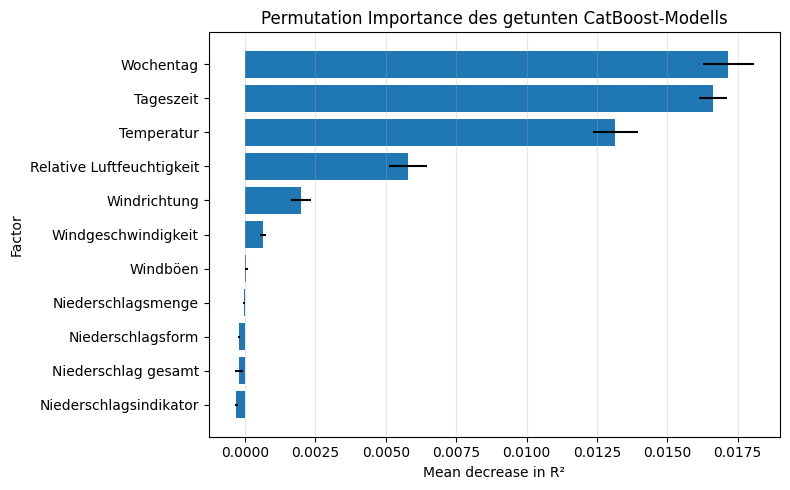

,Factor,Status
11,Feiertag,konstant im Validierungsmonat


,Factor,Importance Mean,Importance Std,Status
0,Wochentag,0.0172,0.0009,ok
1,Tageszeit,0.0166,0.0005,ok
2,Temperatur,0.0132,0.0008,ok
3,Relative Luftfeuchtigkeit,0.0058,0.0007,ok
4,Windrichtung,0.0020,0.0004,ok
5,Windgeschwindigkeit,0.0006,0.0001,ok
6,Windböen,0.0000,0.0001,ok
7,Niederschlagsmenge,-0.0000,0.0000,ok
8,Niederschlagsform,-0.0002,0.0000,ok
9,Niederschlag gesamt,-0.0002,0.0002,ok


In [8]:
plot_data = permutation_importance_results.loc[
    permutation_importance_results["Status"] == "ok"
].sort_values(
    "Importance Mean",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    plot_data["Factor"],
    plot_data["Importance Mean"],
    xerr=plot_data["Importance Std"],
)
ax.set_title("Permutation Importance des getunten CatBoost-Modells")
ax.set_xlabel("Mean decrease in R²")
ax.set_ylabel("Factor")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

constant_groups = permutation_importance_results.loc[
    permutation_importance_results["Status"] != "ok",
    ["Factor", "Status"],
]

if not constant_groups.empty:
    display(constant_groups)

permutation_importance_results.round(4)

## 9. Partial-Dependence-Analyse

Partial Dependence beschreibt die Reaktion des Modells auf Änderungen eines Merkmals, während alle anderen Merkmale unverändert bleiben. Sie ist kein kausaler Effekt und kein beobachteter Mittelwert tatsächlicher Verspätungen. Korrelationen zwischen Wettervariablen können außerdem unrealistische Merkmalskombinationen erzeugen. Die Ergebnisse sind deshalb vorsichtig als modellierte Zusammenhänge zu lesen.

Unter jeder numerischen PDP wird die Spannweite der durchschnittlichen Modellprognose zusätzlich in Minuten und Sekunden ausgewiesen. Dadurch wird sichtbar, ob eine optisch erkennbare Kurve praktisch nur sehr kleine Unterschiede abbildet.

In [9]:
def calculate_numeric_partial_dependence(
    model: CatBoostRegressor,
    X: pd.DataFrame,
    feature: str,
    values: np.ndarray,
) -> pd.DataFrame:
    rows = []

    for value in values:
        X_modified = X.copy()
        X_modified[feature] = value
        mean_prediction = float(np.mean(predict_catboost(model, X_modified)))
        rows.append(
            {
                "Feature": feature,
                "Value": value,
                "Mean Prediction [min]": mean_prediction,
            }
        )

    return pd.DataFrame(rows)


def calculate_categorical_partial_dependence(
    model: CatBoostRegressor,
    X: pd.DataFrame,
    feature: str,
    values: list,
    display_values: list | None = None,
) -> pd.DataFrame:
    if display_values is None:
        display_values = values

    rows = []

    for assigned_value, display_value in zip(values, display_values):
        X_modified = X.copy()
        X_modified[feature] = assigned_value
        mean_prediction = float(np.mean(predict_catboost(model, X_modified)))
        rows.append(
            {
                "Feature": feature,
                "Value": display_value,
                "Assigned Value": assigned_value,
                "Mean Prediction [min]": mean_prediction,
            }
        )

    return pd.DataFrame(rows)


def calculate_wind_direction_partial_dependence(
    model: CatBoostRegressor,
    X: pd.DataFrame,
    angles_degrees: list[int],
) -> pd.DataFrame:
    rows = []

    for angle_degrees in angles_degrees:
        angle_radians = np.deg2rad(angle_degrees)
        X_modified = X.copy()
        X_modified["wind_direction_sin"] = np.sin(angle_radians)
        X_modified["wind_direction_cos"] = np.cos(angle_radians)
        mean_prediction = float(np.mean(predict_catboost(model, X_modified)))
        rows.append(
            {
                "Wind Direction Degrees": angle_degrees,
                "Mean Prediction [min]": mean_prediction,
            }
        )

    return pd.DataFrame(rows)


def evenly_spaced_quantile_grid(
    series: pd.Series,
    lower_quantile: float = 0.05,
    upper_quantile: float = 0.95,
    n_values: int = 20,
) -> np.ndarray:
    numeric_series = pd.to_numeric(series, errors="coerce").dropna()
    lower = numeric_series.quantile(lower_quantile)
    upper = numeric_series.quantile(upper_quantile)

    if np.isclose(lower, upper):
        return np.array([float(lower)])

    return np.linspace(lower, upper, n_values)


def sorted_observed_values(series: pd.Series) -> list:
    values = pd.Series(series.dropna().unique()).tolist()

    def sort_key(value):
        try:
            return (0, float(value))
        except (TypeError, ValueError):
            return (1, str(value))

    return sorted(values, key=sort_key)


def common_observed_values(
    train_series: pd.Series,
    validation_series: pd.Series,
) -> list:
    train_values = set(sorted_observed_values(train_series))
    validation_values = set(sorted_observed_values(validation_series))
    return sorted_observed_values(pd.Series(list(train_values & validation_values)))


def categorical_category_diagnostics(
    feature: str,
    train_series: pd.Series,
    validation_series: pd.Series,
    label_function=None,
) -> pd.DataFrame:
    train_values = set(sorted_observed_values(train_series))
    validation_values = set(sorted_observed_values(validation_series))
    rows = []

    for value in sorted_observed_values(pd.Series(list(train_values | validation_values))):
        in_training = value in train_values
        in_validation = value in validation_values
        if in_training and in_validation:
            status = "Training und Juli"
        elif in_training:
            status = "nur Training"
        else:
            status = "nur Juli"

        rows.append(
            {
                "Feature": feature,
                "Value": label_function(value) if label_function else value,
                "Raw Value": value,
                "Status": status,
            }
        )

    return pd.DataFrame(rows)


def display_non_common_categories(diagnostics: pd.DataFrame) -> None:
    non_common = diagnostics.loc[diagnostics["Status"] != "Training und Juli"]
    if not non_common.empty:
        display(non_common.reset_index(drop=True))


def summarize_pdp_range(
    pdp_result: pd.DataFrame,
    prediction_column: str = "Mean Prediction [min]",
) -> pd.DataFrame:
    minimum = float(pdp_result[prediction_column].min())
    maximum = float(pdp_result[prediction_column].max())
    value_range = maximum - minimum

    return pd.DataFrame(
        {
            "Metric": [
                "Minimum Mean Prediction [min]",
                "Maximum Mean Prediction [min]",
                "Spannweite [min]",
                "Spannweite [sec]",
            ],
            "Value": [
                minimum,
                maximum,
                value_range,
                value_range * 60,
            ],
        }
    )

### 9.1 Zeit- und Kalenderfaktoren

Die Wochentagskodierung basiert auf `pandas.Series.dt.weekday`: 0 = Montag, 1 = Dienstag, 2 = Mittwoch, 3 = Donnerstag, 4 = Freitag, 5 = Samstag, 6 = Sonntag.

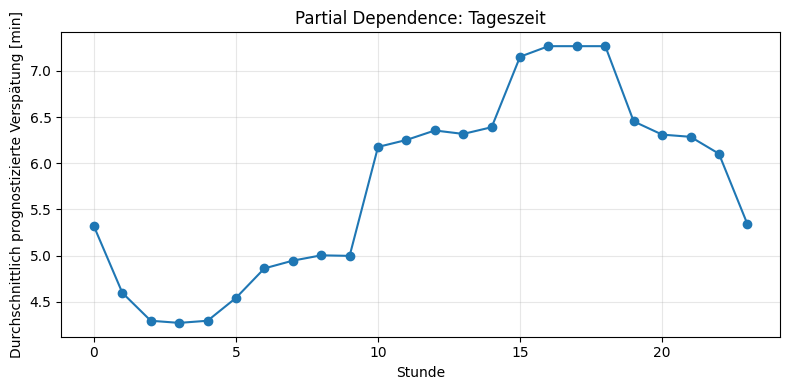

,Feature,Value,Assigned Value,Mean Prediction [min]
0,event_hour,0,0,5.3172
1,event_hour,1,1,4.5975
2,event_hour,2,2,4.2955
3,event_hour,3,3,4.2724
4,event_hour,4,4,4.2955
5,event_hour,5,5,4.5428
6,event_hour,6,6,4.8620
7,event_hour,7,7,4.9458
8,event_hour,8,8,5.0034
9,event_hour,9,9,4.9975


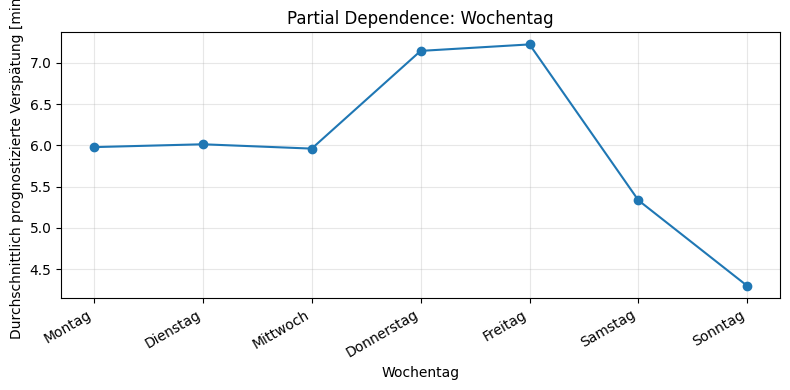

,Feature,Value,Assigned Value,Mean Prediction [min]
0,event_weekday,0,0,5.9803
1,event_weekday,1,1,6.0145
2,event_weekday,2,2,5.9621
3,event_weekday,3,3,7.1464
4,event_weekday,4,4,7.2249
5,event_weekday,5,5,5.3350
6,event_weekday,6,6,4.2973


,Feature,Value,Raw Value,Status
0,is_public_holiday,True,True,nur Training


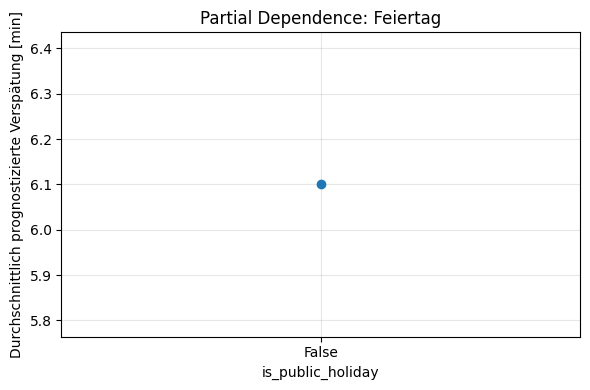

,Feature,Value,Assigned Value,Mean Prediction [min]
0,is_public_holiday,False,False,6.1


In [10]:
event_hour_diagnostics = categorical_category_diagnostics(
    "event_hour",
    X_train_catboost["event_hour"],
    X_interpretation["event_hour"],
)
display_non_common_categories(event_hour_diagnostics)

event_hour_values = common_observed_values(
    X_train_catboost["event_hour"],
    X_interpretation["event_hour"],
)
event_hour_display_values = [int(value) for value in event_hour_values]

event_hour_pd = calculate_categorical_partial_dependence(
    model=catboost_tuned_model,
    X=X_interpretation,
    feature="event_hour",
    values=event_hour_values,
    display_values=event_hour_display_values,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(event_hour_pd["Value"], event_hour_pd["Mean Prediction [min]"], marker="o")
ax.set_title("Partial Dependence: Tageszeit")
ax.set_xlabel("Stunde")
ax.set_ylabel("Durchschnittlich prognostizierte Verspätung [min]")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(event_hour_pd.round(4))

event_weekday_diagnostics = categorical_category_diagnostics(
    "event_weekday",
    X_train_catboost["event_weekday"],
    X_interpretation["event_weekday"],
)
display_non_common_categories(event_weekday_diagnostics)

event_weekday_values = common_observed_values(
    X_train_catboost["event_weekday"],
    X_interpretation["event_weekday"],
)
event_weekday_display_values = [int(value) for value in event_weekday_values]
weekday_labels = [
    "Montag",
    "Dienstag",
    "Mittwoch",
    "Donnerstag",
    "Freitag",
    "Samstag",
    "Sonntag",
]
event_weekday_pd = calculate_categorical_partial_dependence(
    model=catboost_tuned_model,
    X=X_interpretation,
    feature="event_weekday",
    values=event_weekday_values,
    display_values=event_weekday_display_values,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(event_weekday_pd["Value"], event_weekday_pd["Mean Prediction [min]"], marker="o")
ax.set_title("Partial Dependence: Wochentag")
ax.set_xlabel("Wochentag")
ax.set_ylabel("Durchschnittlich prognostizierte Verspätung [min]")
ax.set_xticks(event_weekday_display_values)
ax.set_xticklabels(
    [weekday_labels[value] for value in event_weekday_display_values],
    rotation=30,
    ha="right",
)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(event_weekday_pd.round(4))

holiday_diagnostics = categorical_category_diagnostics(
    "is_public_holiday",
    X_train_catboost["is_public_holiday"],
    X_interpretation["is_public_holiday"],
)
display_non_common_categories(holiday_diagnostics)

holiday_values = common_observed_values(
    X_train_catboost["is_public_holiday"],
    X_interpretation["is_public_holiday"],
)
is_public_holiday_pd = calculate_categorical_partial_dependence(
    model=catboost_tuned_model,
    X=X_interpretation,
    feature="is_public_holiday",
    values=holiday_values,
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    range(len(is_public_holiday_pd)),
    is_public_holiday_pd["Mean Prediction [min]"],
    marker="o",
)
ax.set_title("Partial Dependence: Feiertag")
ax.set_xlabel("is_public_holiday")
ax.set_ylabel("Durchschnittlich prognostizierte Verspätung [min]")
ax.set_xticks(range(len(holiday_values)))
ax.set_xticklabels([str(value) for value in holiday_values])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

is_public_holiday_pd.round(4)

### 9.2 Temperatur und Luftfeuchtigkeit

Die folgenden PDPs zeigen die CatBoost-Modellreaktion auf Temperatur und relative Luftfeuchtigkeit, keinen kausalen Effekt. Zusätzlich werden einfache Verteilungs- und Häufigkeitsdiagnosen für Training und Juli ausgegeben. Wenn hohe Werte im Training selten sind, ist die Interpretation der PDP in diesen Bereichen entsprechend eingeschränkt.

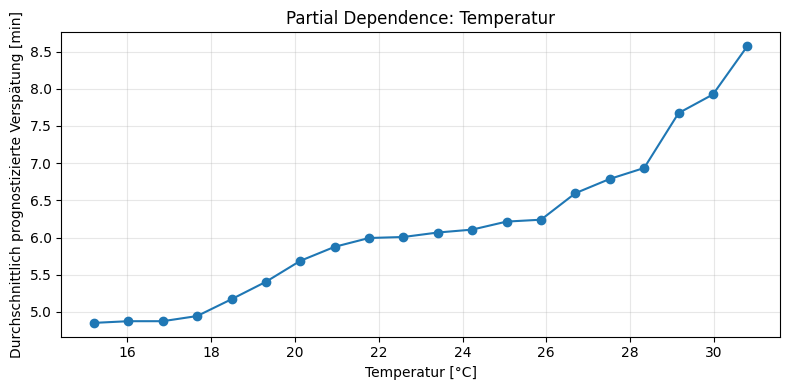

,Feature,Value,Mean Prediction [min]
0,tu_temperature_c,15.2000,4.8528
1,tu_temperature_c,16.0211,4.8755
2,tu_temperature_c,16.8421,4.8755
3,tu_temperature_c,17.6632,4.9447
4,tu_temperature_c,18.4842,5.1707
5,tu_temperature_c,19.3053,5.4050
6,tu_temperature_c,20.1263,5.6864
7,tu_temperature_c,20.9474,5.8751
8,tu_temperature_c,21.7684,5.9936
9,tu_temperature_c,22.5895,6.0072


,Metric,Value
0,Minimum Mean Prediction [min],4.8528
1,Maximum Mean Prediction [min],8.5718
2,Spannweite [min],3.7191
3,Spannweite [sec],223.1450


In [11]:
temperature_grid = evenly_spaced_quantile_grid(X_interpretation["tu_temperature_c"])
temperature_pd = calculate_numeric_partial_dependence(
    model=catboost_tuned_model,
    X=X_interpretation,
    feature="tu_temperature_c",
    values=temperature_grid,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(temperature_pd["Value"], temperature_pd["Mean Prediction [min]"], marker="o")
ax.set_title("Partial Dependence: Temperatur")
ax.set_xlabel("Temperatur [°C]")
ax.set_ylabel("Durchschnittlich prognostizierte Verspätung [min]")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(temperature_pd.round(4))
summarize_pdp_range(temperature_pd).round(4)

,Dataset,Feature,Metric,Value
0,Training,tu_temperature_c,Observations,689684.000
1,Training,tu_temperature_c,Missing,1494.000
2,Training,tu_temperature_c,Min,-12.800
3,Training,tu_temperature_c,Q05,-0.300
4,Training,tu_temperature_c,Median,9.200
5,Training,tu_temperature_c,Q95,24.700
6,Training,tu_temperature_c,Max,39.900
7,Training,tu_temperature_c,> 25,32923.000
8,Training,tu_temperature_c,> 25 [% valid],4.784
9,Training,tu_temperature_c,> 30,11801.000


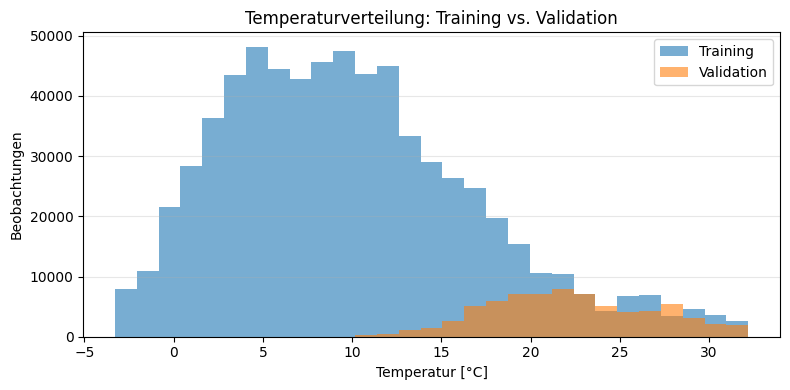

In [12]:
def summarize_numeric_distribution(
    dataset_name: str,
    features: pd.DataFrame,
    feature: str,
    high_thresholds: list[float],
) -> pd.DataFrame:
    values = pd.to_numeric(features[feature], errors="coerce")
    rows = [
        {
            "Dataset": dataset_name,
            "Feature": feature,
            "Metric": "Observations",
            "Value": len(values),
        },
        {
            "Dataset": dataset_name,
            "Feature": feature,
            "Metric": "Missing",
            "Value": int(values.isna().sum()),
        },
        {
            "Dataset": dataset_name,
            "Feature": feature,
            "Metric": "Min",
            "Value": values.min(),
        },
        {
            "Dataset": dataset_name,
            "Feature": feature,
            "Metric": "Q05",
            "Value": values.quantile(0.05),
        },
        {
            "Dataset": dataset_name,
            "Feature": feature,
            "Metric": "Median",
            "Value": values.median(),
        },
        {
            "Dataset": dataset_name,
            "Feature": feature,
            "Metric": "Q95",
            "Value": values.quantile(0.95),
        },
        {
            "Dataset": dataset_name,
            "Feature": feature,
            "Metric": "Max",
            "Value": values.max(),
        },
    ]

    valid_count = int(values.notna().sum())
    for threshold in high_thresholds:
        count = int((values > threshold).sum())
        rows.append(
            {
                "Dataset": dataset_name,
                "Feature": feature,
                "Metric": f"> {threshold:g}",
                "Value": count,
            }
        )
        rows.append(
            {
                "Dataset": dataset_name,
                "Feature": feature,
                "Metric": f"> {threshold:g} [% valid]",
                "Value": count / valid_count * 100 if valid_count else np.nan,
            }
        )

    return pd.DataFrame(rows)


temperature_humidity_distribution = pd.concat(
    [
        summarize_numeric_distribution(
            "Training",
            X_train,
            "tu_temperature_c",
            high_thresholds=[25, 30],
        ),
        summarize_numeric_distribution(
            "Validation",
            X_validation,
            "tu_temperature_c",
            high_thresholds=[25, 30],
        ),
        summarize_numeric_distribution(
            "Training",
            X_train,
            "tu_relative_humidity_pct",
            high_thresholds=[80, 90],
        ),
        summarize_numeric_distribution(
            "Validation",
            X_validation,
            "tu_relative_humidity_pct",
            high_thresholds=[80, 90],
        ),
    ],
    ignore_index=True,
)

display(temperature_humidity_distribution.round(3))

combined_temperature = pd.concat(
    [X_train["tu_temperature_c"], X_validation["tu_temperature_c"]],
    ignore_index=True,
)
combined_temperature = pd.to_numeric(combined_temperature, errors="coerce").dropna()
temperature_histogram_bins = np.linspace(
    combined_temperature.quantile(0.01),
    combined_temperature.quantile(0.99),
    30,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    pd.to_numeric(X_train["tu_temperature_c"], errors="coerce").dropna(),
    bins=temperature_histogram_bins,
    alpha=0.6,
    label="Training",
)
ax.hist(
    pd.to_numeric(X_validation["tu_temperature_c"], errors="coerce").dropna(),
    bins=temperature_histogram_bins,
    alpha=0.6,
    label="Validation",
)
ax.set_title("Temperaturverteilung: Training vs. Validation")
ax.set_xlabel("Temperatur [°C]")
ax.set_ylabel("Beobachtungen")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

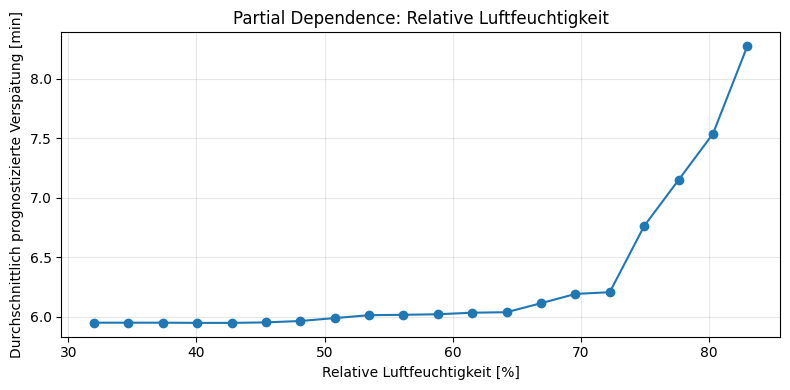

,Feature,Value,Mean Prediction [min]
0,tu_relative_humidity_pct,32.0000,5.9506
1,tu_relative_humidity_pct,34.6842,5.9506
2,tu_relative_humidity_pct,37.3684,5.9506
3,tu_relative_humidity_pct,40.0526,5.9489
4,tu_relative_humidity_pct,42.7368,5.9489
5,tu_relative_humidity_pct,45.4211,5.9531
6,tu_relative_humidity_pct,48.1053,5.9647
7,tu_relative_humidity_pct,50.7895,5.9891
8,tu_relative_humidity_pct,53.4737,6.0136
9,tu_relative_humidity_pct,56.1579,6.0167


,Metric,Value
0,Minimum Mean Prediction [min],5.9489
1,Maximum Mean Prediction [min],8.2725
2,Spannweite [min],2.3236
3,Spannweite [sec],139.4181


In [13]:
humidity_grid = evenly_spaced_quantile_grid(X_interpretation["tu_relative_humidity_pct"])
humidity_pd = calculate_numeric_partial_dependence(
    model=catboost_tuned_model,
    X=X_interpretation,
    feature="tu_relative_humidity_pct",
    values=humidity_grid,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(humidity_pd["Value"], humidity_pd["Mean Prediction [min]"], marker="o")
ax.set_title("Partial Dependence: Relative Luftfeuchtigkeit")
ax.set_xlabel("Relative Luftfeuchtigkeit [%]")
ax.set_ylabel("Durchschnittlich prognostizierte Verspätung [min]")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(humidity_pd.round(4))
summarize_pdp_range(humidity_pd).round(4)

### 9.3 Wind


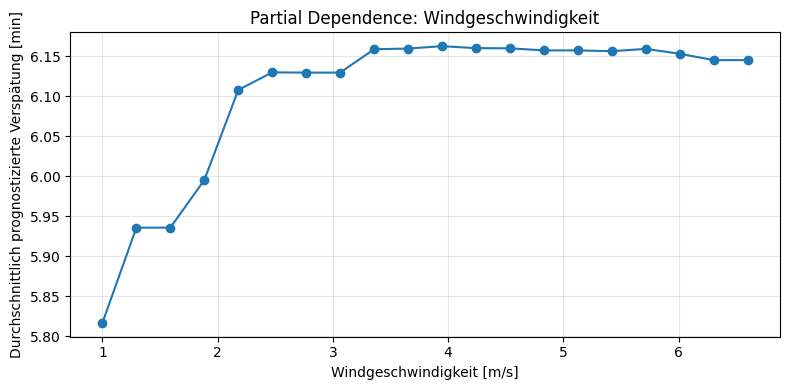

,Feature,Value,Mean Prediction [min]
0,ff_wind_speed_ms,1.0000,5.8164
1,ff_wind_speed_ms,1.2947,5.9356
2,ff_wind_speed_ms,1.5895,5.9356
3,ff_wind_speed_ms,1.8842,5.9951
4,ff_wind_speed_ms,2.1789,6.1078
5,ff_wind_speed_ms,2.4737,6.1298
6,ff_wind_speed_ms,2.7684,6.1295
7,ff_wind_speed_ms,3.0632,6.1295
8,ff_wind_speed_ms,3.3579,6.1587
9,ff_wind_speed_ms,3.6526,6.1596


,Metric,Value
0,Minimum Mean Prediction [min],5.8164
1,Maximum Mean Prediction [min],6.1625
2,Spannweite [min],0.3461
3,Spannweite [sec],20.7666


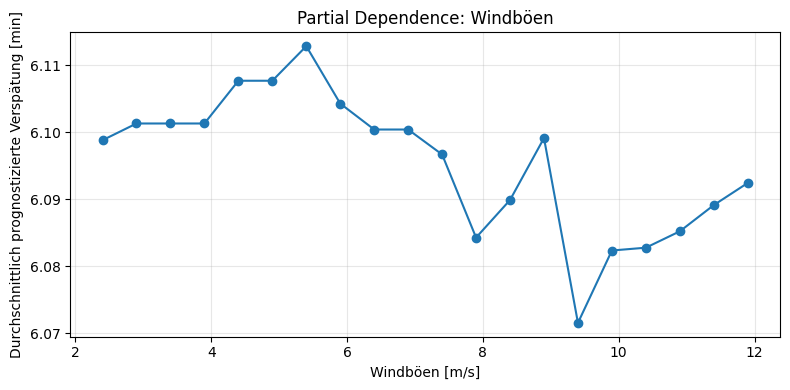

,Feature,Value,Mean Prediction [min]
0,fx_wind_gust_ms,2.4,6.0988
1,fx_wind_gust_ms,2.9,6.1013
2,fx_wind_gust_ms,3.4,6.1013
3,fx_wind_gust_ms,3.9,6.1013
4,fx_wind_gust_ms,4.4,6.1077
5,fx_wind_gust_ms,4.9,6.1077
6,fx_wind_gust_ms,5.4,6.1129
7,fx_wind_gust_ms,5.9,6.1043
8,fx_wind_gust_ms,6.4,6.1004
9,fx_wind_gust_ms,6.9,6.1004


,Metric,Value
0,Minimum Mean Prediction [min],6.0715
1,Maximum Mean Prediction [min],6.1129
2,Spannweite [min],0.0413
3,Spannweite [sec],2.4797


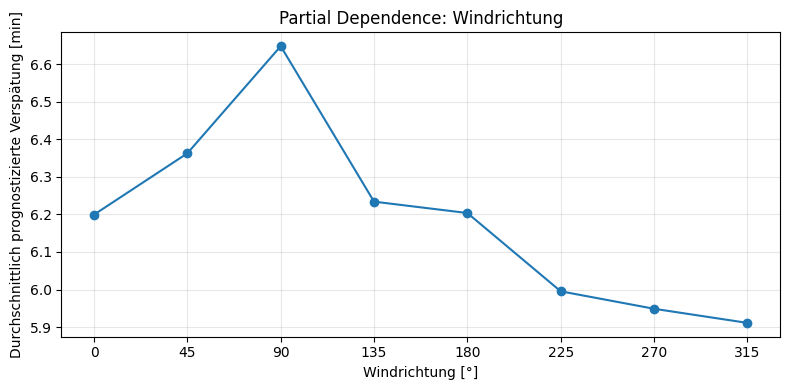

,Wind Direction Degrees,Mean Prediction [min]
0,0,6.1994
1,45,6.3627
2,90,6.6480
3,135,6.2340
4,180,6.2037
5,225,5.9952
6,270,5.9487
7,315,5.9111


,Metric,Value
0,Minimum Mean Prediction [min],5.9111
1,Maximum Mean Prediction [min],6.6480
2,Spannweite [min],0.7369
3,Spannweite [sec],44.2143


In [14]:
wind_speed_grid = evenly_spaced_quantile_grid(X_interpretation["ff_wind_speed_ms"])
wind_speed_pd = calculate_numeric_partial_dependence(
    model=catboost_tuned_model,
    X=X_interpretation,
    feature="ff_wind_speed_ms",
    values=wind_speed_grid,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(wind_speed_pd["Value"], wind_speed_pd["Mean Prediction [min]"], marker="o")
ax.set_title("Partial Dependence: Windgeschwindigkeit")
ax.set_xlabel("Windgeschwindigkeit [m/s]")
ax.set_ylabel("Durchschnittlich prognostizierte Verspätung [min]")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(wind_speed_pd.round(4))
display(summarize_pdp_range(wind_speed_pd).round(4))

wind_gust_grid = evenly_spaced_quantile_grid(X_interpretation["fx_wind_gust_ms"])
wind_gust_pd = calculate_numeric_partial_dependence(
    model=catboost_tuned_model,
    X=X_interpretation,
    feature="fx_wind_gust_ms",
    values=wind_gust_grid,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(wind_gust_pd["Value"], wind_gust_pd["Mean Prediction [min]"], marker="o")
ax.set_title("Partial Dependence: Windböen")
ax.set_xlabel("Windböen [m/s]")
ax.set_ylabel("Durchschnittlich prognostizierte Verspätung [min]")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(wind_gust_pd.round(4))
display(summarize_pdp_range(wind_gust_pd).round(4))

wind_direction_angles = [0, 45, 90, 135, 180, 225, 270, 315]
wind_direction_pd = calculate_wind_direction_partial_dependence(
    model=catboost_tuned_model,
    X=X_interpretation,
    angles_degrees=wind_direction_angles,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    wind_direction_pd["Wind Direction Degrees"],
    wind_direction_pd["Mean Prediction [min]"],
    marker="o",
)
ax.set_title("Partial Dependence: Windrichtung")
ax.set_xlabel("Windrichtung [°]")
ax.set_ylabel("Durchschnittlich prognostizierte Verspätung [min]")
ax.set_xticks(wind_direction_angles)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(wind_direction_pd.round(4))
summarize_pdp_range(wind_direction_pd).round(4)

### 9.4 Niederschlag

Die Niederschlagsvariablen werden sowohl einzeln als auch in der Permutation Importance gemeinsam betrachtet, weil `rr_precipitation_mm`, `rr_precipitation_indicator` und `rr_precipitation_form` fachlich zusammengehören.

Die folgenden PDPs zeigen, wie sich die durchschnittliche Modellvorhersage verändert, wenn ein Niederschlagsmerkmal künstlich gesetzt wird. Das ist kein beobachteter durchschnittlicher Verspätungsunterschied bei dieser Regenmenge oder Kategorie. Wegen der Abhängigkeit zwischen Niederschlagsmenge, Indikator und Niederschlagsform sind isolierte PDPs vorsichtig zu interpretieren.

Im Projekt wurde keine dokumentierte Zuordnung der `WRTR`-Codes zu Niederschlagsformen gefunden. Deshalb werden die kodierten DWD-Kategorien nicht fachlich umbenannt; `missing` wird lediglich als fehlende Angabe gekennzeichnet.

,Metric,Value
0,Observations total,73867.0000
1,Missing,0.0000
2,rr_precipitation_mm == 0,72523.0000
3,rr_precipitation_mm > 0,1344.0000
4,Share zero [%],98.1805
5,Positive min,0.1000
6,Positive median,0.3000
7,Positive max,4.8000


,Quantile,rr_precipitation_mm
0,0.10,0.1
1,0.25,0.1
2,0.50,0.3
3,0.75,0.6
4,0.90,1.4
5,0.95,1.4


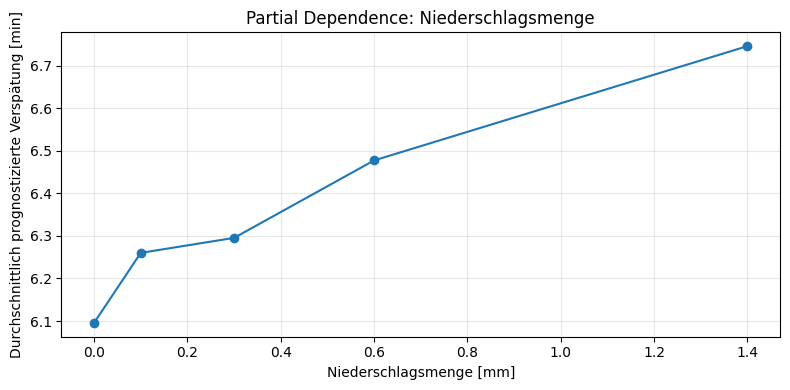

,Feature,Value,Mean Prediction [min]
0,rr_precipitation_mm,0.0,6.0956
1,rr_precipitation_mm,0.1,6.2600
2,rr_precipitation_mm,0.3,6.2952
3,rr_precipitation_mm,0.6,6.4772
4,rr_precipitation_mm,1.4,6.7456


,Metric,Value
0,Minimum Mean Prediction [min],6.0956
1,Maximum Mean Prediction [min],6.7456
2,Spannweite [min],0.6500
3,Spannweite [sec],38.9972


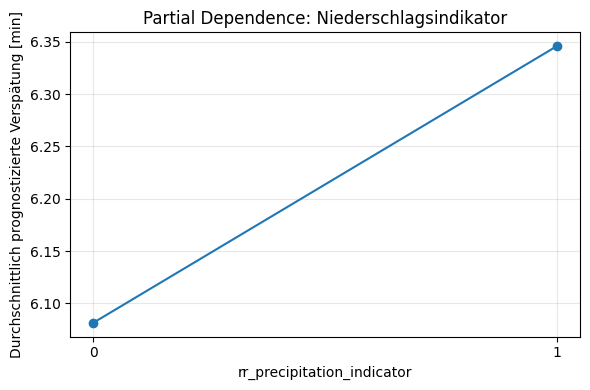

,Feature,Value,Assigned Value,Mean Prediction [min]
0,rr_precipitation_indicator,0.0,0.0,6.0816
1,rr_precipitation_indicator,1.0,1.0,6.3459


,Feature,Value,Raw Value,Status
0,rr_precipitation_form,Code 0.0,0.0,Training und Juli
1,rr_precipitation_form,Code 4.0,4.0,nur Training
2,rr_precipitation_form,Code 6.0,6.0,Training und Juli
3,rr_precipitation_form,Code 7.0,7.0,nur Training
4,rr_precipitation_form,Code 8.0,8.0,nur Training
5,rr_precipitation_form,fehlende Angabe,missing,nur Training


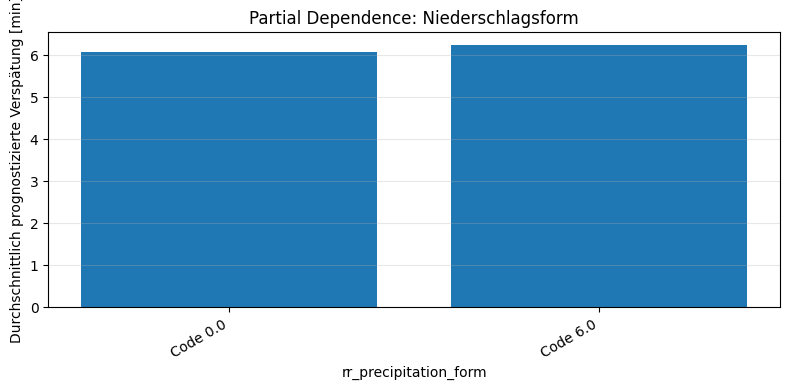

,Feature,Value,Assigned Value,Mean Prediction [min]
0,rr_precipitation_form,Code 0.0,0.0,6.0929
1,rr_precipitation_form,Code 6.0,6.0,6.2393


In [15]:
precipitation_series = pd.to_numeric(
    X_interpretation["rr_precipitation_mm"],
    errors="coerce",
)
positive_precipitation = precipitation_series[precipitation_series > 0]
positive_precipitation_quantiles = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95]

precipitation_diagnosis = pd.DataFrame(
    {
        "Metric": [
            "Observations total",
            "Missing",
            "rr_precipitation_mm == 0",
            "rr_precipitation_mm > 0",
            "Share zero [%]",
            "Positive min",
            "Positive median",
            "Positive max",
        ],
        "Value": [
            len(precipitation_series),
            int(precipitation_series.isna().sum()),
            int((precipitation_series == 0).sum()),
            int((precipitation_series > 0).sum()),
            (precipitation_series == 0).mean() * 100,
            positive_precipitation.min() if not positive_precipitation.empty else np.nan,
            positive_precipitation.median() if not positive_precipitation.empty else np.nan,
            positive_precipitation.max() if not positive_precipitation.empty else np.nan,
        ],
    }
)

display(precipitation_diagnosis.round(4))

if positive_precipitation.empty:
    precipitation_positive_quantiles = pd.DataFrame(
        columns=["Quantile", "rr_precipitation_mm"]
    )
    precipitation_grid = np.array([0.0])
    precipitation_pd = pd.DataFrame(
        columns=["Feature", "Value", "Mean Prediction [min]"]
    )
    print(
        "Im Juli gibt es keine positiven Niederschlagswerte. "
        "Eine PDP-Verlaufsauswertung der Niederschlagsmenge ist daher nicht sinnvoll."
    )
else:
    precipitation_positive_quantiles = pd.DataFrame(
        {
            "Quantile": positive_precipitation_quantiles,
            "rr_precipitation_mm": positive_precipitation.quantile(
                positive_precipitation_quantiles,
                interpolation="nearest",
            ).to_numpy(),
        }
    )
    precipitation_grid = np.array(
        sorted(
            {
                0.0,
                *precipitation_positive_quantiles["rr_precipitation_mm"].tolist(),
            }
        )
    )
    precipitation_grid = precipitation_grid[precipitation_grid >= 0]
    precipitation_pd = calculate_numeric_partial_dependence(
        model=catboost_tuned_model,
        X=X_interpretation,
        feature="rr_precipitation_mm",
        values=precipitation_grid,
    )

    display(precipitation_positive_quantiles.round(4))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(precipitation_pd["Value"], precipitation_pd["Mean Prediction [min]"], marker="o")
    ax.set_title("Partial Dependence: Niederschlagsmenge")
    ax.set_xlabel("Niederschlagsmenge [mm]")
    ax.set_ylabel("Durchschnittlich prognostizierte Verspätung [min]")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    display(precipitation_pd.round(4))
    display(summarize_pdp_range(precipitation_pd).round(4))

precipitation_indicator_values = common_observed_values(
    X_train_catboost["rr_precipitation_indicator"],
    X_interpretation["rr_precipitation_indicator"],
)
precipitation_indicator_pd = calculate_categorical_partial_dependence(
    model=catboost_tuned_model,
    X=X_interpretation,
    feature="rr_precipitation_indicator",
    values=precipitation_indicator_values,
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    precipitation_indicator_pd["Value"],
    precipitation_indicator_pd["Mean Prediction [min]"],
    marker="o",
)
ax.set_title("Partial Dependence: Niederschlagsindikator")
ax.set_xlabel("rr_precipitation_indicator")
ax.set_ylabel("Durchschnittlich prognostizierte Verspätung [min]")
ax.set_xticks(precipitation_indicator_values)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(precipitation_indicator_pd.round(4))


def format_precipitation_form_label(value) -> str:
    if value == "missing":
        return "fehlende Angabe"
    return f"Code {value}"


precipitation_form_diagnostics = categorical_category_diagnostics(
    "rr_precipitation_form",
    X_train_catboost["rr_precipitation_form"],
    X_interpretation["rr_precipitation_form"],
    label_function=format_precipitation_form_label,
)
display(precipitation_form_diagnostics)

precipitation_form_values = common_observed_values(
    X_train_catboost["rr_precipitation_form"],
    X_interpretation["rr_precipitation_form"],
)
precipitation_form_labels = [
    format_precipitation_form_label(value) for value in precipitation_form_values
]
precipitation_form_pd = calculate_categorical_partial_dependence(
    model=catboost_tuned_model,
    X=X_interpretation,
    feature="rr_precipitation_form",
    values=precipitation_form_values,
    display_values=precipitation_form_labels,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    range(len(precipitation_form_pd)),
    precipitation_form_pd["Mean Prediction [min]"],
)
ax.set_title("Partial Dependence: Niederschlagsform")
ax.set_xlabel("rr_precipitation_form")
ax.set_ylabel("Durchschnittlich prognostizierte Verspätung [min]")
ax.set_xticks(range(len(precipitation_form_labels)))
ax.set_xticklabels(precipitation_form_labels, rotation=30, ha="right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

precipitation_form_pd.round(4)

## 10. Zusammenfassung der Modellinterpretation

Die gruppierte Permutation Importance untersucht die relative prognostische Bedeutung der fachlichen Einflussfaktoren im getunten CatBoost-Modell. Die gemeinsame Niederschlagsgruppe prüft ergänzend die zusammenhängende Niederschlagsinformation. Die Partial-Dependence-Auswertungen zeigen die Form der Modellreaktion auf einzelne Merkmale, während die übrigen Merkmale unverändert bleiben.

Konstante Merkmale im Juli können mit Permutation Importance für diesen Validierungsmonat nicht beurteilt werden. Aus den Ergebnissen werden keine kausalen Wirkungen abgeleitet. Die konkrete Ergebnisinterpretation erfolgt anschließend anhand der tatsächlich erzeugten Tabellen und Grafiken.